### **Analiza danych obrazowych i multimedialnych**

### **WaveNet**

Autorzy: Michał Pigoń, Paweł Mazurkiewicz, Sebastian Pietrykowski, Wojciech Wójcik

Data realizacji: 01.06.2026 

WaveNet – model sieci neuronowej opracowany przez DeepMind do generowania i syntezy dźwięku, szczególnie mowy.

Sieć ta służy przede wszystkim do: syntezy mowy, generowania muzyki i innych sygnałów audio, oraz do poprawy jakości systemów text to speech

WaveNet generuje dźwięki próbka po próbce. Na podstawie wcześniej wygenerowanych próbek przewiduje kolejną próbkę fali dźwiękowej.Wykorzystuje ona głęboką sieć konwolucyjną ze splotami przyczynowymi (causal convolution) oraz przyczynowymi splotami rozszerzonymi (dilated causal convolution).

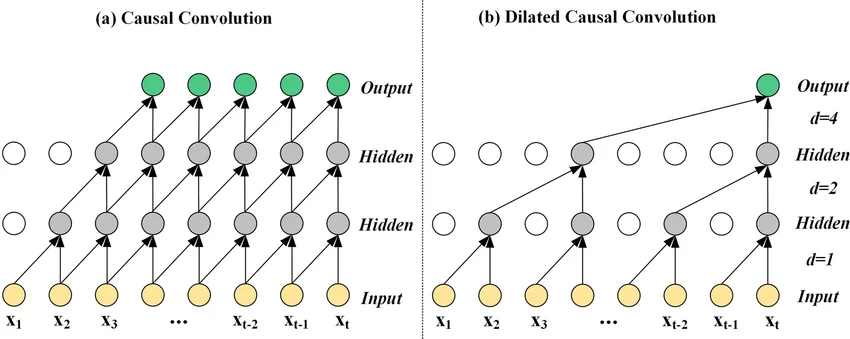

Więcej informacji odnośnie wybranego modelu:

https://arxiv.org/pdf/1609.03499

https://github.com/ibab/tensorflow-wavenet

##### **Parametry WaveNet**

filter_width - Szerokość filtra konwolucyjnego. Określa ile sąsiednich próbek jest analizowanych jednocześnie

sample_rate - Częstotliwość próbkowania audio (Hz)

dilations - Współczynniki dylatacji kolejnych warstw. Decydują o zasięgu czasowym modelu

residual_channels - Liczba kanałów w ścieżce residual. Określa pojemność modelu

dilation_channels - Liczba kanałów w warstwach z przyczynowymi splotami rozszerzonymi (dilated convolution)

quantization_channels - Liczba poziomów kwantyzacji sygnału audio

skip_channels - Liczba kanałów połączeń skip. Łączą informacje z wielu warstw przed wyjściem

skip_connection_scale - Skaluje wkład połączeń skip

use_biases - Czy używać biasów w warstwach

scalar_input - Typ wejścia. false = wejście skwantowane (one-hot), true = surowa wartość próbki

initial_filter_width - Rozmiar pierwszego filtra wejściowego

**Przykładowe ustawienie parametrów w pliku wavenet_params.json**

```json
{
    "filter_width": 2,
    "sample_rate": 16000,
    "dilations": [1, 2, 4, 8, 16, 32, 64, 128, 256, 512,
                  1, 2, 4, 8, 16, 32, 64, 128, 256, 512,
                  1, 2, 4, 8, 16, 32, 64, 128, 256, 512,
                  1, 2, 4, 8, 16, 32, 64, 128, 256, 512,
                  1, 2, 4, 8, 16, 32, 64, 128, 256, 512],
    "residual_channels": 32,
    "dilation_channels": 32,
    "quantization_channels": 256,
    "skip_channels": 512,
    "skip_connection_scale": 1.0,
    "use_biases": true,
    "scalar_input": false,
    "initial_filter_width": 32
}
```


##### **Trening modelu**

Trening odbywał się na zbiorze VCTK-Corpus https://www.kaggle.com/datasets/pratt3000/vctk-corpus?resource=download. Zawiera on próbki mowy w języku angielskim.

In [4]:
!python train.py --data_dir=./VCTK-Corpus --num_steps 10

Using default logdir: ./logdir\train\2026-06-02T20-07-48
Trying to restore saved checkpoints from ./logdir\train\2026-06-02T20-07-48 ... No checkpoint found.
files length: 44242
step 0 - loss = 5.551, (3.003 sec/step)
Storing checkpoint to ./logdir\train\2026-06-02T20-07-48 ... Done.
step 1 - loss = 5.553, (3.648 sec/step)
step 2 - loss = 5.555, (0.479 sec/step)
step 3 - loss = 5.544, (0.563 sec/step)
step 4 - loss = 5.548, (1.515 sec/step)
step 5 - loss = 5.540, (0.454 sec/step)
step 6 - loss = 5.541, (0.350 sec/step)
step 7 - loss = 5.538, (2.446 sec/step)
step 8 - loss = 5.519, (0.243 sec/step)
step 9 - loss = 5.528, (0.189 sec/step)
Storing checkpoint to ./logdir\train\2026-06-02T20-07-48 ... Done.
Training finished at: 2026-06-02 20:08:08
Program finished.


I0000 00:00:1780423658.220153   14160 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780423663.681602   14160 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

Instructions for updating:
non-resource variables are not supported in the long term
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Use `tf.cast` instead.
Instructions for updating:
Use `tf.cast` instead.
Instructions for updating:
Deprecated in favor of operator or tf.math.divide.
Instructions for updating:

Future major versions of Ten

##### **Generowanie dźwięku korzystając z wytrenowanego modelu**

In [1]:
import json
import numpy as np
import soundfile as sf

import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

from wavenet import WaveNetModel, mu_law_decode

from IPython.display import Audio


Instructions for updating:
non-resource variables are not supported in the long term


In [6]:
SAMPLES = 16000
TEMPERATURE = 1.0
WAVENET_PARAMS = './wavenet_params_default.json'
WAV_OUT = "generated.wav"

In [7]:
def generate_audio(model_dir, wavenet_params):
    net = WaveNetModel(
        batch_size=1,
        dilations=wavenet_params['dilations'],
        filter_width=wavenet_params['filter_width'],
        residual_channels=wavenet_params['residual_channels'],
        dilation_channels=wavenet_params['dilation_channels'],
        quantization_channels=wavenet_params['quantization_channels'],
        skip_channels=wavenet_params['skip_channels'],
        use_biases=wavenet_params['use_biases'],
        scalar_input=wavenet_params['scalar_input'],
        initial_filter_width=wavenet_params['initial_filter_width'],
        global_condition_channels=None,
        global_condition_cardinality=None
    )

    samples = tf.placeholder(tf.int32)

    next_sample = net.predict_proba(samples)

    decode = mu_law_decode(
        samples,
        wavenet_params["quantization_channels"]
    )

    sess = tf.Session()

    variables_to_restore = {
        var.name[:-2]: var for var in tf.global_variables()
        if not ('state_buffer' in var.name or 'pointer' in var.name)
    }

    saver = tf.train.Saver(variables_to_restore)
    saver.restore(sess, model_dir)

    print("Model załadowany")

    quantization_channels = wavenet_params["quantization_channels"]

    waveform = (
        [quantization_channels // 2]
        * (net.receptive_field - 1)
    )

    waveform.append(
        np.random.randint(quantization_channels)
    )

    for step in range(SAMPLES):
        if len(waveform) > net.receptive_field:
            window = waveform[-net.receptive_field:]
        else:
            window = waveform
        outputs = [next_sample]

        prediction = sess.run(outputs, feed_dict={samples: window})[0]

        scaled_prediction = np.log(
            np.maximum(prediction, 1e-12)
        ) / TEMPERATURE
        scaled_prediction = (scaled_prediction -
                                np.logaddexp.reduce(scaled_prediction))
        scaled_prediction = np.exp(scaled_prediction)
        if TEMPERATURE == 1.0:
                np.testing.assert_allclose(
                        prediction, scaled_prediction, atol=1e-5,
                        err_msg='Prediction scaling at temperature=1.0 '
                                'is not working as intended.')

        sample = np.random.choice(
            np.arange(quantization_channels),
            p=scaled_prediction
        )

        waveform.append(sample)

    audio = sess.run(
        decode,
        feed_dict={samples: waveform}
    )

    return audio
    

**Przykład modelu trenowanego na domyślnych parametrach przez 10k kroków**

In [8]:
with open(WAVENET_PARAMS, 'r') as config_file:
    wavenet_params = json.load(config_file)

In [11]:
model_dir = './logdir/train/2026-05-19T19-24-02/model.ckpt-9999'

audio = generate_audio(model_dir, wavenet_params)

INFO:tensorflow:Restoring parameters from ./logdir/train/2026-05-19T19-24-02/model.ckpt-9999
Model załadowany


In [12]:
Audio(
    audio,
    rate=wavenet_params["sample_rate"]
)

Model generuje głównie szumy ze względu na to, że trenowany był tylko na 10k kroków, w porównaniu z 100k, na których trenowali model badacze.

Przed wczytaniem kolejnego modelu należy oczyścić graf.

In [28]:
tf.reset_default_graph()

**Alternatywny sposób generowania dźwięku - użycie komendy**

`python generate.py --wav_out_path=generated.wav --samples 16000 logdir/train/2017-02-13T16-45-34/model.ckpt-80000`

W tym przypadku korzystamy z modelu wytrenowanego na 80k kroków, znajdujący się w lokalizacji, gdzie program generujący model domyślnie go zapisze (kolejne utworzone modele rozróżniane są przez znacznik czasu oznaczający początek treningu).

**Przykład modelu trenowanego na domyślnych parametrach przez 20k kroków**

Nieznaczna poprawa w porównaniu do 10k kroków - tonacja już bardziej przypomina mowę, ale dalej przypomina to bardziej szum niż mowę.

In [4]:
Audio(filename='./Sprawozdanie/audio/default_20k_steps_audio_v3_fast.wav')

**Model z sample rate 4000** 

Aby wytrenować model dla innej częstotliwości próbkowania należało przeprowadzić resampling całego zbioru treningowego, a także
zmienić w wavenet_params.json "sample_rate": 4000.

In [2]:
Audio(filename='./Sprawozdanie/audio/4k_sample_rate.wav')

Podczas naszych testów model ten generował na początku coś na wzór ludzkiej mowy

**Model ze zmianą Gated Activation na Swish-Gated Linear Unit (SwiGLU)**

Zmiana w wavenet_params.json względem konfiguracji bazowej: "gated_activation": "swish_gated"

Najlepszy wynik

In [25]:
Audio(filename='./Sprawozdanie/audio/gated_activation_swish_gated_steps_20k_no_5.wav')

Dźwięki wygenerowane przez model przypominają ciężki sprzęt

**Zmiana dylatacji modelu**

Zmiana w wavenet_params.json względem konfiguracji bazowej - więcej rzędów i więcej kolumn (poszerzenie pola receptywnego)
```json
"dilations": [1, 2, 4, 8, 16, 32, 64, 128, 256,
              1, 2, 4, 8, 16, 32, 64, 128, 256,
              1, 2, 4, 8, 16, 32, 64, 128, 256,
              1, 2, 4, 8, 16, 32, 64, 128, 256,
              1, 2, 4, 8, 16, 32, 64, 128, 256,
              1, 2, 4, 8, 16, 32, 64, 128, 256] # 6 rzędów, 9 kolumn
```

Najlepszy wynik

In [26]:
Audio(filename='./Sprawozdanie/audio/dilations_3_steps_20k_no_2.wav')

Dźwięki generowane przez ten model przypominają trochę syczenie człowieka

**Model ze zmienionym parametrem mu-law (mu=63, quantization_channels=64)**

In [3]:
Audio(filename='./Sprawozdanie/audio/mu_law_63.wav')

Wynik tego eksperymentu jest wyraźnie bardziej skompresowany niż próbka generowana przez model domyślny. Jest to spowodowane mniejszą liczbą klas rozróżnianych przez funkcję straty, wynikającą z niższej wartości parametru mu. Próbka jest więc rekonstruowana z bardziej ograniczonego zbioru wartości, co prowadzi do większej kompresji kosztem utraty części informacji

**Zwiększenie kroków do 100k**

Ze względu na ograniczenia sprzętowe, nasze treningi kończyliśmy 10k - 20k kroków (ok. 5-6h), co nie pozwalało na wygenerowanie zadowalających próbek.

Karl Hiner we wpisie na swoim blogu "Generating Music with WaveNet and SampleRNN" (https://karlhiner.com/music_generation/wavenet_and_samplernn/)
udokumentował eksperymenty z wykorzystaniem 100k kroków (co w naszym przypadku trwałoby ponad 30h). 

Pozwoliło to już na wygenerowanie próbek, które można uznać za zadowalające.

Autor eksperymentował także ze zwiększeniem liczby kroków z 100k do 200k oraz liczby próbek do 320k i 640k (u nas 16k), jednak nie przyniosło to zauważalnej poprawy.

Najlepszy wynik

In [2]:
Audio(filename='./Sprawozdanie/audio/Dom_-_Largemodel_-_200ksteps_-_320000samples_KLICKAUD.mp3')

##### **Wnioski**

Model WaveNet umożliwia skuteczne modelowanie i generowanie sygnałów mowy. Jest on jednak obarczony pewnymi wadami, o których powienien wiedzieć każdy kto chce użyć tego rozwiązania. Po pierwsze, jeżeli trenujemy własny model musimy brać pod uwagę to, że czas treningu będzie bardzo długi. Można go skrócić dopiero gdy posiada się naprawdę dobrą kartę graficzną. Na naszych komputerach czas treningu dla 10k kroków wynosił około 5-6 godzin, a żeby zyskać satysfakcjonującą generację, trzeba by model trenować przez 100k kroków. Po drugie, samo generowanie sekundowych próbek zajmuje po kilka minut, co w niektórych zastosowaniach może być niedopuszczalne. 

Jakość generowanego sygnału jest też silnie zależna od ustawionych parametrów. Z naszych doświadczeń wynika, że największy wpływ ma liczba kroków (a więc długośc samego teningu), choć nie jest to czynnik przesądzający. Spośród innych parametrów, największy sukces odnieśliśmy po zmniejszeniu sample rate na 4k, co w niektórych próbkach skutkowało czymś co można nazwać początkiem ludzkiej mowy. Zmiany innych parametrów nie przyniosły podobnych rezultatów i skutkowały raczej szumem, czy to bardziej skompresowanym czy brzmiącym jak ciężka maszyneria.

Prawdopodobnym wyjaśnieniem dobrego działania modelu wytrenowanego na zmniejszonej częstotliwości próbkowania jest fakt, że pominięta została większość energii zawarta w sybilantach obecnych w ludzkiej mowie. Dzięki temu stosunkowo mała liczba kroków wystarczyła do wygenerowania czegoś co przypomina przytłumioną (pozbawioną wysokich częstotliwości) mowę. Dodatkowo zmiana częstotliwości wydłużyła czas patrzenia wstecz modelu - mniejsza ilość próbek na sekundę oznacza, że ta sama architektura jest w stanie wychwycić bardziej długofalowe zależności.

Modele trenowane zbyt krótko albo ze złym doborem parametrów skutkowały generowaniem dźwieku przypominającym biały szum. Dłuższy trening lub lepszy dobór parametrów skutkowały mniej "szumiącym" dźwiękiem, w którym można było już wyczuć rytm, zmianę tonacji. Jednak w żadnym przypadku nie był to dźwięk krystaliczny - zawsze zdarzały się lekkie szumy.

Metoda ta może być skutecznie używana do syntezy mowy, ale należy mieć na uwadze wyżej wymienione wady i przeciwności z jakimi użytkownik będzie musiał się zmagać.